# Experiment 5: Risk Decomposition and the Value of Diversification

**Question 1:** Does Component VaR (the parametric closed-form decomposition) actually sum to
total portfolio VaR, as the math claims it should?

**Question 2:** Does diversification meaningfully reduce risk for this equity universe -- and does
a more concentrated portfolio show a smaller diversification benefit than an equal-weighted one, as
theory predicts?

**Method:** Real returns for the project's ingested equity universe, real covariance matrix,
`portfolio/decomposition.py`'s Marginal/Component VaR, and `portfolio/calculations.py`'s
diversification-benefit metric (sum of standalone VaRs minus portfolio VaR).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from risk_engine.db.session import SessionLocal
from risk_engine.db.queries import get_returns_matrix
from risk_engine.risk_models.parametric import parametric_var, portfolio_variance
from risk_engine.risk_models.historical import historical_var
from risk_engine.portfolio.decomposition import marginal_var, component_var, pct_contribution
from risk_engine.portfolio.calculations import herfindahl_hirschman_index, diversification_benefit

TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "JPM", "JNJ", "PG", "XOM", "XLK"]
CONFIDENCE = 0.95
LOOKBACK_DAYS = 250

db = SessionLocal()
as_of_date = db.execute(__import__("sqlalchemy").text("SELECT max(price_date) FROM prices")).scalar()
returns_matrix = get_returns_matrix(db, TICKERS, as_of_date, LOOKBACK_DAYS)
mu_vector = returns_matrix.mean().to_numpy()
cov_matrix = returns_matrix.cov().to_numpy()
print(f"Loaded {returns_matrix.shape[0]} days x {returns_matrix.shape[1]} assets as of {as_of_date}")

Loaded 250 days x 10 assets as of 2026-08-05


In [2]:
weights = {t: 1.0 / len(TICKERS) for t in TICKERS}
w_array = np.array([weights[t] for t in returns_matrix.columns])
mu_p = float(w_array @ mu_vector)
sigma_p = float(np.sqrt(portfolio_variance(w_array, cov_matrix)))
portfolio_var = parametric_var(mu_p, sigma_p, CONFIDENCE)

mvar = marginal_var(w_array, mu_vector, cov_matrix, CONFIDENCE, sigma_p)
cvars = component_var(w_array, mvar)
pcts = pct_contribution(cvars, portfolio_var)

decomp_df = pd.DataFrame({"ticker": returns_matrix.columns, "weight": w_array, "marginal_var": mvar, "component_var": cvars, "pct_contribution": pcts})
decomp_df = decomp_df.sort_values("component_var", ascending=False).reset_index(drop=True)

sum_component_var = decomp_df["component_var"].sum()
print(f"Portfolio parametric VaR (95%):        {portfolio_var:.4%}")
print(f"Sum of Component VaR across positions: {sum_component_var:.4%}")
print(f"Difference:                            {abs(portfolio_var - sum_component_var):.2e}  (should be ~machine epsilon)")
decomp_df

Portfolio parametric VaR (95%):        1.1416%
Sum of Component VaR across positions: 1.1416%
Difference:                            1.73e-18  (should be ~machine epsilon)


,ticker,weight,marginal_var,component_var,pct_contribution
0,NVDA,0.1,0.023438,0.002344,0.205314
1,AMZN,0.1,0.022944,0.002294,0.200991
2,GOOGL,0.1,0.018356,0.001836,0.160801
3,MSFT,0.1,0.017630,0.001763,0.154440
4,XLK,0.1,0.016424,0.001642,0.143877
5,AAPL,0.1,0.010065,0.001007,0.088172
6,JPM,0.1,0.009465,0.000946,0.082912
7,PG,0.1,0.001969,0.000197,0.017246
8,JNJ,0.1,-0.002067,-0.000207,-0.018108
9,XOM,0.1,-0.004069,-0.000407,-0.035644


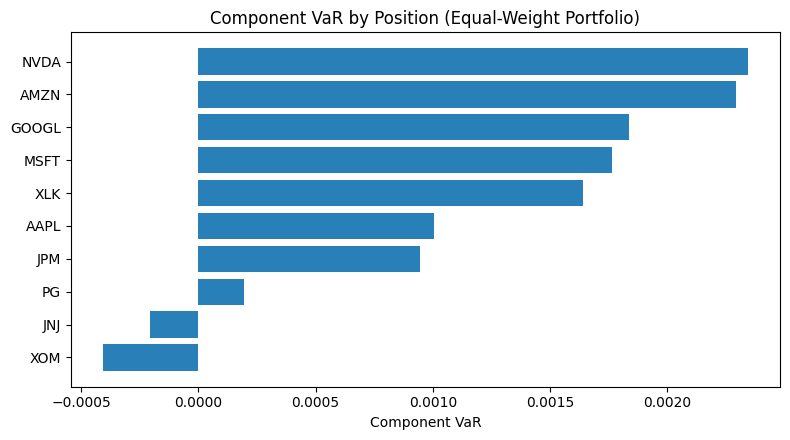

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(decomp_df["ticker"], decomp_df["component_var"], color="#2980b9")
ax.invert_yaxis()
ax.set_xlabel("Component VaR")
ax.set_title("Component VaR by Position (Equal-Weight Portfolio)")
fig.tight_layout()
plt.show()

## Experiment 5: Diversification Benefit Across Portfolio Constructions

Compare portfolio VaR against the sum of standalone (isolated, ignoring correlation) position
VaRs, for three constructions of the same 10-asset universe: equal-weight, moderately
concentrated, and highly concentrated. Theory predicts the diversification benefit should shrink
as concentration increases.

In [4]:
n = len(TICKERS)
constructions = {
    "equal_weight": np.full(n, 1.0 / n),
    "moderately_concentrated": np.array([0.30, 0.20, 0.15, 0.10] + [0.25 / (n - 4)] * (n - 4)),
    "highly_concentrated": np.array([0.70] + [0.30 / (n - 1)] * (n - 1)),
}

rows = []
for name, w in constructions.items():
    w = w / w.sum()  # normalise exactly to 1.0
    sigma_p = float(np.sqrt(portfolio_variance(w, cov_matrix)))
    mu_p = float(w @ mu_vector)
    port_var = parametric_var(mu_p, sigma_p, CONFIDENCE)

    standalone_vars = {}
    for i, ticker in enumerate(returns_matrix.columns):
        asset_returns = returns_matrix[ticker].to_numpy()
        standalone_vars[ticker] = w[i] * historical_var(asset_returns, CONFIDENCE)

    benefit = diversification_benefit(standalone_vars, port_var)
    hhi = herfindahl_hirschman_index({t: w[i] for i, t in enumerate(returns_matrix.columns)})
    rows.append({"construction": name, "hhi": hhi, "portfolio_var": port_var, "sum_standalone_var": sum(standalone_vars.values()), "diversification_benefit": benefit, "benefit_pct": benefit / sum(standalone_vars.values())})

div_df = pd.DataFrame(rows).set_index("construction")
div_df

,hhi,portfolio_var,sum_standalone_var,diversification_benefit,benefit_pct
construction,,,,,
equal_weight,0.100000,0.011416,0.025839,0.014424,0.558208
moderately_concentrated,0.172917,0.014885,0.025153,0.010268,0.408235
highly_concentrated,0.500000,0.018458,0.022562,0.004104,0.181913


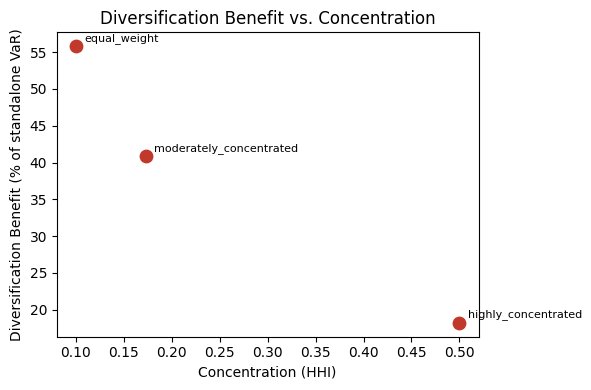

As HHI rises from 0.100 to 0.500, the diversification
benefit (% of standalone VaR) decreases (55.8% -> 18.2%).
This is consistent with theory: concentrating a portfolio into fewer, more correlated
positions leaves less room for the covariance matrix to reduce aggregate risk.


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(div_df["hhi"], div_df["benefit_pct"] * 100, s=80, color="#c0392b")
for name, row in div_df.iterrows():
    ax.annotate(name, (row["hhi"], row["benefit_pct"] * 100), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("Concentration (HHI)")
ax.set_ylabel("Diversification Benefit (% of standalone VaR)")
ax.set_title("Diversification Benefit vs. Concentration")
fig.tight_layout()
plt.show()

correlation_direction = "decreases" if div_df["benefit_pct"].iloc[0] > div_df["benefit_pct"].iloc[-1] else "does not decrease"
print(f"As HHI rises from {div_df['hhi'].min():.3f} to {div_df['hhi'].max():.3f}, the diversification")
print(f"benefit (% of standalone VaR) {correlation_direction} "
      f"({div_df['benefit_pct'].iloc[0]:.1%} -> {div_df['benefit_pct'].iloc[-1]:.1%}).")
if correlation_direction == "decreases":
    print("This is consistent with theory: concentrating a portfolio into fewer, more correlated")
    print("positions leaves less room for the covariance matrix to reduce aggregate risk.")

## Limitations

- Standalone VaR here uses Historical VaR per position (matching the blueprint's diversification-
  benefit definition); Component VaR above uses the Parametric closed form -- these are
  deliberately different methodologies for different purposes and should not be compared directly
  position-by-position.
- The "moderately concentrated" and "highly concentrated" weight constructions are illustrative,
  not derived from any optimisation -- they exist to demonstrate the HHI-vs-benefit relationship,
  not to recommend an allocation.